#### Imports

In [15]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import glob
import re
import matplotlib.pyplot as plt

In [16]:
def load_adjlist_to_mtx(mtx_filename, nodes_filename):
    adj_mtx = np.loadtxt(mtx_filename, dtype=int)
    with open(nodes_filename, 'r') as f:
        nodes = [line.strip() for line in f.readlines()]
    return adj_mtx, nodes

adj_mtx2_dengue, nodes2_dengue = load_adjlist_to_mtx('output/grafo2_dengue_mtx.txt', 'output/grafo2_dengue_nodes.txt')
adj_mtx3_dengue, nodes3_dengue = load_adjlist_to_mtx('output/grafo3_dengue_mtx.txt', 'output/grafo3_dengue_nodes.txt')
adj_mtx1_mob, nodes1_mob = load_adjlist_to_mtx('output/grafo1_mob_mtx.txt', 'output/grafo1_mob_nodes.txt')
adj_mtx2_mob, nodes2_mob = load_adjlist_to_mtx('output/grafo2_mob_mtx.txt', 'output/grafo2_mob_nodes.txt')
adj_mtx3_mob, nodes3_mob = load_adjlist_to_mtx('output/grafo3_mob_mtx.txt', 'output/grafo3_mob_nodes.txt')

adj_dengue = [adj_mtx2_dengue, adj_mtx3_dengue]
adj_mob = [adj_mtx1_mob, adj_mtx2_mob, adj_mtx3_mob]

In [17]:
if nodes2_dengue!=nodes1_mob:
    raise ValueError('The graphs do not have the same set of nodes.')

In [18]:
def compare_adjacency_matrices_frobenius(matrix1, matrix2):
    if matrix1.shape != matrix2.shape:
        raise ValueError("Matrices have different shapes")
    
    frobenius_norm = np.linalg.norm(matrix1 - matrix2, ord='fro')
    return frobenius_norm

i = 1
j = 1
for dengue_mtx in adj_dengue:
    for mob_mtx in adj_mob:

        frob = compare_adjacency_matrices_frobenius(mob_mtx, dengue_mtx)
        print(f'Grafo dengue {i} - Grafo mob {j} - diff: {frob}')
        j+=1
    i+=1
    j=1

Grafo dengue 1 - Grafo mob 1 - diff: 39.84971769034255
Grafo dengue 1 - Grafo mob 2 - diff: 13.341664064126334
Grafo dengue 1 - Grafo mob 3 - diff: 10.488088481701515
Grafo dengue 2 - Grafo mob 1 - diff: 39.26830783214372
Grafo dengue 2 - Grafo mob 2 - diff: 16.492422502470642
Grafo dengue 2 - Grafo mob 3 - diff: 14.560219778561036


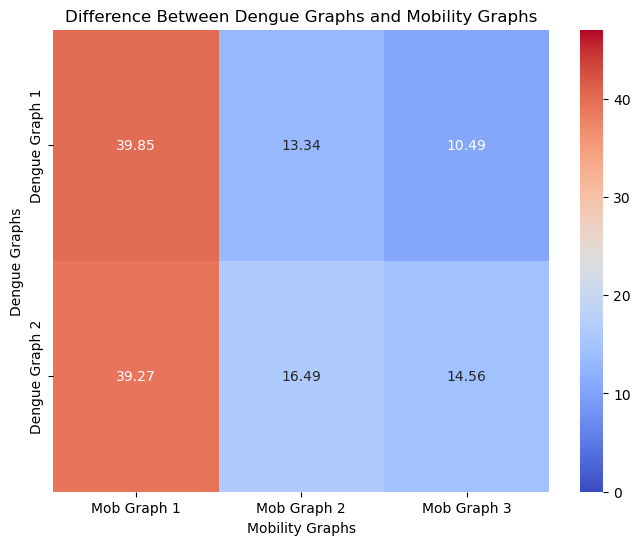

In [19]:
# Provided data
data = [
    [39.84971769034255, 13.341664064126334, 10.488088481701515],
    [39.26830783214372, 16.492422502470642, 14.560219778561036]
]

# Row and column names
x_labels = ['Mob Graph 1', 'Mob Graph 2', 'Mob Graph 3']
y_labels = ['Dengue Graph 1', 'Dengue Graph 2']

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=47, xticklabels=x_labels, yticklabels=y_labels)

# Title and labels
plt.title("Difference Between Dengue Graphs and Mobility Graphs")
plt.xlabel("Mobility Graphs")
plt.ylabel("Dengue Graphs")

# Show the plot
plt.show()


In [29]:
# Function to extract the number from the filename
def extract_number(filename):
    match = re.search(r'threshold_(\d+)', filename)
    return int(match.group(1)) if match else float('inf')

# Function to extract the number from the filename as a float
def extract_float(filename):
    match = re.search(r'threshold_(\d+\.\d+)', filename)
    return float(match.group(1)) if match else float('inf')

# File pattern
mob_file_pattern = 'output/mtx_mob/'+'filtered_adj_matrix_threshold_*.txt'
mob_filtered_files = glob.glob(mob_file_pattern)
# Sort files based on the extracted number
mob_filtered_files.sort(key=extract_number)
# Display sorted files
# mob_filtered_files

# Generate the list of files matching the pattern
file_pattern = 'output/mtx_dengue/'+'filtered_adj_matrix_threshold_0*.txt'
filtered_files = glob.glob(file_pattern)
filtered_files.sort(key=extract_float)
# filtered_files = filtered_files[:-8] # Removing the last file that contains only zeros
# filtered_files

# Function to compare two matrices using the Frobenius norm
def compare_adjacency_matrices_frobenius(matrix1, matrix2):
    if matrix1.shape != matrix2.shape:
        raise ValueError("Matrices have different shapes")
    # Frobenius norm: sqrt(sum of squared differences)
    frobenius_norm = np.linalg.norm(matrix1 - matrix2, ord='fro')
    return frobenius_norm

triples = []
mob_idx = np.arange(0, 22050, 10)
dengue_idx = np.arange(0, 1, 0.02)

count_mob = 0
count_cases = 0

# Iterate over the files
for comparison_file in mob_filtered_files:
    i = mob_idx[count_mob]
    comparison_matrix = np.loadtxt(comparison_file, dtype=int)
    if not np.any(comparison_matrix):  # Check if the comparison matrix contains only zeros
        print(f'Comparison matrix {comparison_file} contains only zeros. Skipping...')
        count_mob += 1
        continue
    for cases_filtered_file in filtered_files:
        j = dengue_idx[count_cases]
        filtered_matrix = np.loadtxt(cases_filtered_file, dtype=int)
        if not np.any(filtered_matrix):  # Check if the filtered matrix contains only zeros
            # print(f'Filtered matrix {cases_filtered_file} contains only zeros. Skipping...')
            count_cases += 1
            continue
        differences = compare_adjacency_matrices_frobenius(filtered_matrix, comparison_matrix)
        # if differences > 1:
        #     print('something is wrong')
        triples.append((i, j, differences))
        count_cases += 1
    count_mob += 1
    count_cases = 0

triples


[(0, 0.0, 23.15167380558045),
 (0, 0.02, 23.065125189341593),
 (0, 0.04, 22.847319317591726),
 (0, 0.06, 22.627416997969522),
 (0, 0.08, 22.80350850198276),
 (0, 0.1, 22.715633383201094),
 (0, 0.12, 23.15167380558045),
 (0, 0.14, 23.874672772626646),
 (0, 0.16, 24.454038521274967),
 (0, 0.18, 25.37715508089904),
 (0, 0.2, 26.229754097208),
 (0, 0.22, 26.94438717061496),
 (0, 0.24, 27.568097504180443),
 (0, 0.26, 29.120439557122072),
 (0, 0.28, 30.23243291566195),
 (0, 0.3, 31.336879231984796),
 (0, 0.32, 32.46536616149585),
 (0, 0.34, 34.058772731852805),
 (0, 0.36, 35.09985754956849),
 (0, 0.38, 36.22154055254967),
 (0, 0.4, 37.20215047547655),
 (0, 0.42, 37.97367509209505),
 (0, 0.44, 38.65229618017538),
 (0, 0.46, 39.319206502675),
 (0, 0.48, 39.44616584663204),
 (0, 0.5, 39.67366884975475),
 (0, 0.52, 39.74921382870358),
 (0, 0.54, 40.049968789001575),
 (0, 0.56, 40.19950248448356),
 (0, 0.58, 40.27406113120453),
 (0, 0.6, 40.29888335921977),
 (0, 0.62, 40.34848200366403),
 (0, 0.6

In [30]:
len(triples)

72765

In [31]:
# Get all unique values of the first element from the triples
unique_first_elements = set(triple[0] for triple in triples)
unique_first_elements

filtered_triples = []

# Iterate over each unique value of the first element
for value in unique_first_elements:
    
    filtered_list = []
    for triple in triples: 
        if triple[0] == value:
            filtered_list.append(triple)
    min_triple = (0,0,10000)
    for triple in filtered_list:
        if(triple[2] < min_triple[2]):
            min_triple = triple
    filtered_triples.append(min_triple)

filtered_triples

[(0, 0.06, 22.627416997969522),
 (16390, 0.64, 2.0),
 (8200, 0.64, 4.69041575982343),
 (10, 0.1, 22.58317958127243),
 (16400, 0.64, 2.0),
 (8210, 0.64, 4.69041575982343),
 (20, 0.1, 22.715633383201094),
 (16410, 0.64, 2.0),
 (8220, 0.64, 4.69041575982343),
 (30, 0.1, 22.891046284519195),
 (16420, 0.64, 2.0),
 (8230, 0.64, 4.69041575982343),
 (40, 0.12, 23.323807579381203),
 (16430, 0.64, 2.0),
 (8240, 0.64, 4.69041575982343),
 (50, 0.12, 23.83275057562597),
 (16440, 0.64, 2.0),
 (8250, 0.64, 4.69041575982343),
 (60, 0.12, 23.916521486202797),
 (16450, 0.64, 2.0),
 (8260, 0.64, 4.69041575982343),
 (70, 0.12, 24.331050121192877),
 (16460, 0.64, 2.0),
 (8270, 0.64, 4.69041575982343),
 (80, 0.12, 24.859605789312106),
 (16470, 0.64, 2.0),
 (8280, 0.64, 4.69041575982343),
 (90, 0.14, 25.099800796022265),
 (16480, 0.64, 2.0),
 (8290, 0.64, 4.69041575982343),
 (100, 0.14, 25.298221281347036),
 (16490, 0.64, 2.0),
 (8300, 0.64, 4.69041575982343),
 (110, 0.16, 25.37715508089904),
 (16500, 0.64, 

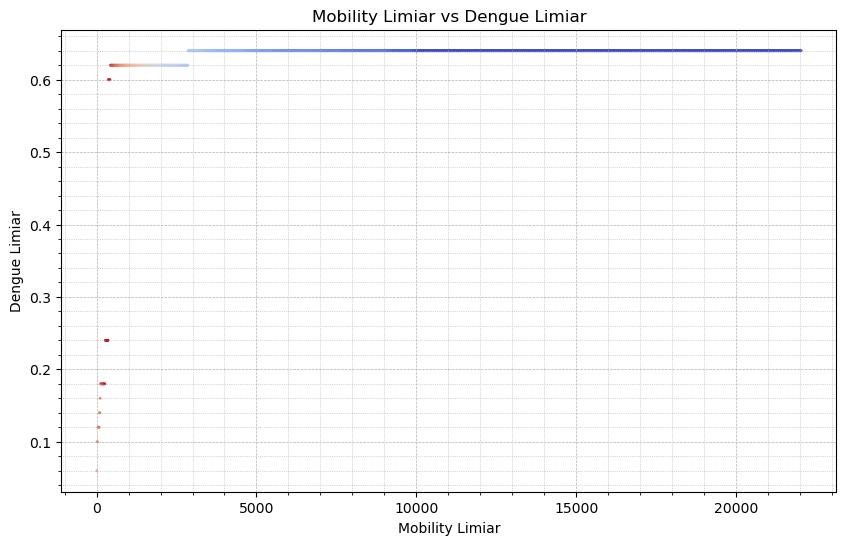

In [32]:
x_values = [triple[0] for triple in filtered_triples]
y_values = [triple[1] for triple in filtered_triples]
color_values = [triple[2] for triple in filtered_triples]

plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, c=color_values, cmap='coolwarm', alpha=0.7, s=1)
plt.xlabel('Mobility Limiar')
plt.ylabel('Dengue Limiar')

plt.title('Mobility Limiar vs Dengue Limiar')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()  
plt.grid(True, which='minor', linestyle=':', linewidth=0.5) 

plt.show()

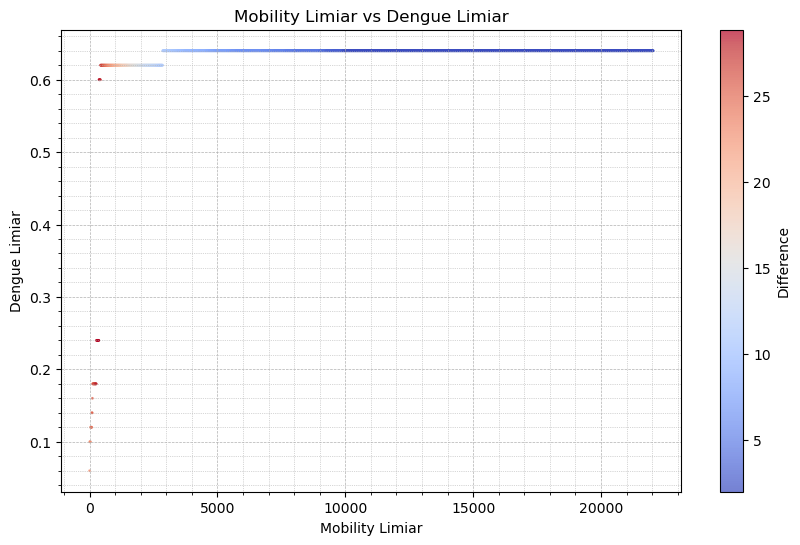

In [33]:
x_values = [triple[0] for triple in filtered_triples]
y_values = [triple[1] for triple in filtered_triples]
color_values = [triple[2] for triple in filtered_triples]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_values, y_values, c=color_values, cmap='coolwarm', alpha=0.7, s=1)

cbar = plt.colorbar(scatter)
cbar.set_label('Difference')

plt.xlabel('Mobility Limiar')
plt.ylabel('Dengue Limiar')
plt.title('Mobility Limiar vs Dengue Limiar')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth=0.5)
plt.show()

#### Log-Log Scale

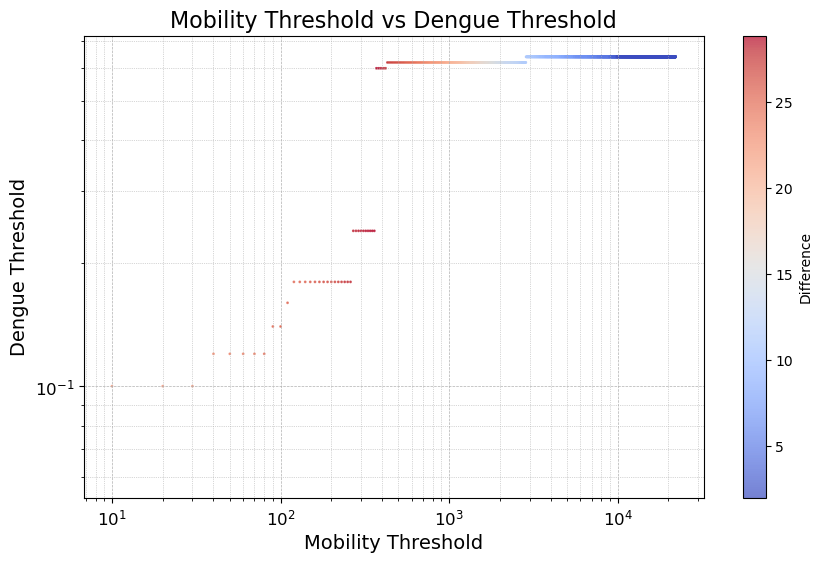

In [34]:
# Separating values for plotting
x_values = [triple[0] for triple in filtered_triples]
y_values = [triple[1] for triple in filtered_triples]
color_values = [triple[2] for triple in filtered_triples]

# Creating the plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_values, y_values, c=color_values, cmap='coolwarm', alpha=0.7, s=1)

# Adding the color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Difference')

# Axis titles with adjusted font size
plt.xlabel('Mobility Threshold', fontsize=14)
plt.ylabel('Dengue Threshold', fontsize=14)

# Plot title with adjusted font size
plt.title('Mobility Threshold vs Dengue Threshold', fontsize=16)

# Configuring the grid with adjusted font size for ticks
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()  # Enables minor ticks
plt.grid(True, which='minor', linestyle=':', linewidth=0.5)  # Style for minor ticks

# Adjusting tick font size
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=10)

# Setting log scale
plt.xscale('log')
plt.yscale('log')

# Displaying the plot
plt.show()


### Invertendo a busca, primeiro for pelo dengue limiar

In [35]:
unique_first_elements = set(triple[1] for triple in triples)
unique_first_elements
filtered_triples = []

for value in unique_first_elements:
    filtered_list = []
    for triple in triples: 
        if triple[1] == value:
            filtered_list.append(triple)
    min_triple = (0,0,10000)
    for triple in filtered_list:
        if(triple[2] < min_triple[2]):
            min_triple = triple
    filtered_triples.append(min_triple)

filtered_triples

[(0, 0.0, 23.15167380558045),
 (0, 0.06, 22.627416997969522),
 (20, 0.12, 22.891046284519195),
 (30, 0.14, 23.280893453645632),
 (30, 0.18, 24.413111231467404),
 (50, 0.2, 25.059928172283335),
 (9890, 0.36, 24.979991993593593),
 (190, 0.3, 28.24889378365107),
 (1140, 0.32, 28.600699292150182),
 (9890, 0.34, 27.27636339397171),
 (9980, 0.42, 18.16590212458495),
 (9980, 0.5, 10.677078252031311),
 (50, 0.26, 27.202941017470888),
 (9980, 0.6, 4.0),
 (9980, 0.52, 9.797958971132712),
 (9980, 0.44, 15.556349186104045),
 (0, 0.04, 22.847319317591726),
 (150, 0.28, 27.85677655436824),
 (9980, 0.62, 2.8284271247461903),
 (10, 0.1, 22.58317958127243),
 (30, 0.16, 23.62202362203543),
 (50, 0.22, 25.41653005427767),
 (9980, 0.54, 8.246211251235321),
 (9980, 0.46, 13.490737563232042),
 (9980, 0.38, 22.538855339169288),
 (0, 0.02, 23.065125189341593),
 (9980, 0.64, 2.0),
 (10, 0.08, 22.67156809750927),
 (9980, 0.48, 12.165525060596439),
 (9980, 0.56, 6.6332495807108),
 (9980, 0.4, 20.29778313018444),

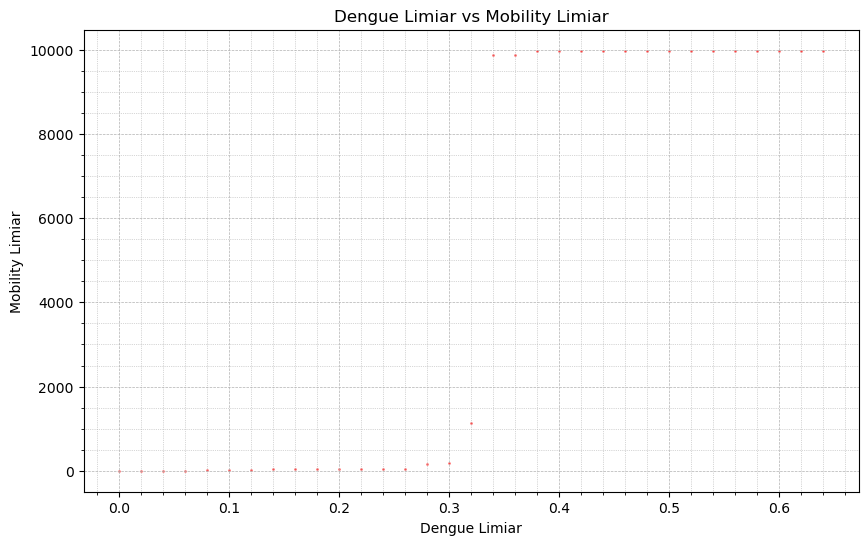

In [36]:
x_values = [triple[0] for triple in filtered_triples]
y_values = [triple[1] for triple in filtered_triples]

plt.figure(figsize=(10, 6))
plt.scatter(y_values, x_values, color='red', alpha=0.5, s=1)

plt.ylabel('Mobility Limiar')
plt.xlabel('Dengue Limiar')
plt.title('Dengue Limiar vs Mobility Limiar')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()  # Ativa os menores ticks
plt.grid(True, which='minor', linestyle=':', linewidth=0.5)  # Estilo para os menores ticks

plt.show()

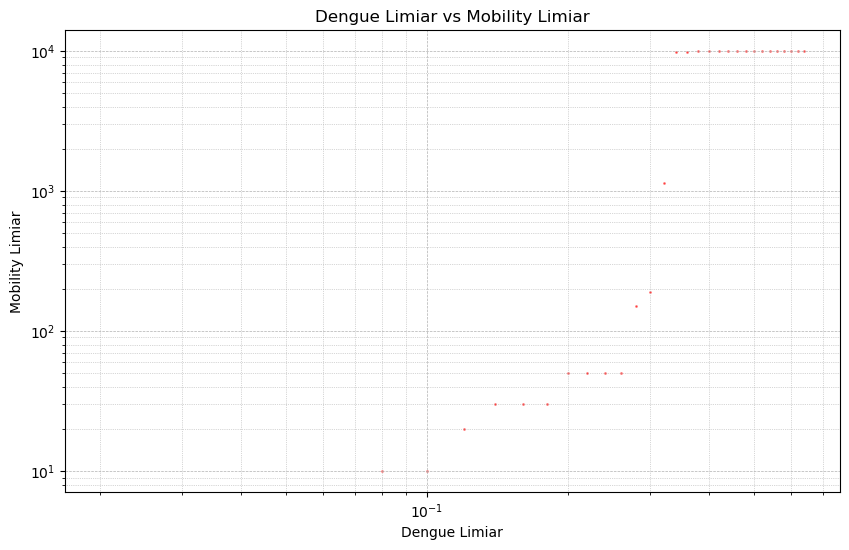

In [38]:
x_values = [triple[0] for triple in filtered_triples]
y_values = [triple[1] for triple in filtered_triples]

plt.figure(figsize=(10, 6))
plt.scatter(y_values, x_values, color='red', alpha=0.5, s=1)
plt.ylabel('Mobility Limiar')
plt.xlabel('Dengue Limiar')
plt.title('Dengue Limiar vs Mobility Limiar')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth=0.5) 

plt.xscale('log')
plt.yscale('log')
plt.show()